# Notebook for Finding the Center of Diffraction Images

**Don't forget to update globals.py with detector information before running this code**

## Import Necessary Packages

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import trxrd
from globals import *

%matplotlib widget

## Define File Paths

In [ ]:
# Main diffraction data folder
data_path = DATA_PATH

# Check number of files in folder 
file_names = sorted(data_path.glob(f"{SCAN_NAME}*.tif"))
print(f"{len(file_names)} TIFF files found in {data_path}.")

884 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3.
Using mask file: C:\Users\lheald\Box\TRXRDPython\testdata\mask_2021_dec.tif


## Import Images

884 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3 with scan name BTO400nmS3_240Ksurv3.


c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd.py:226: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(test + 1), cmap="jet")


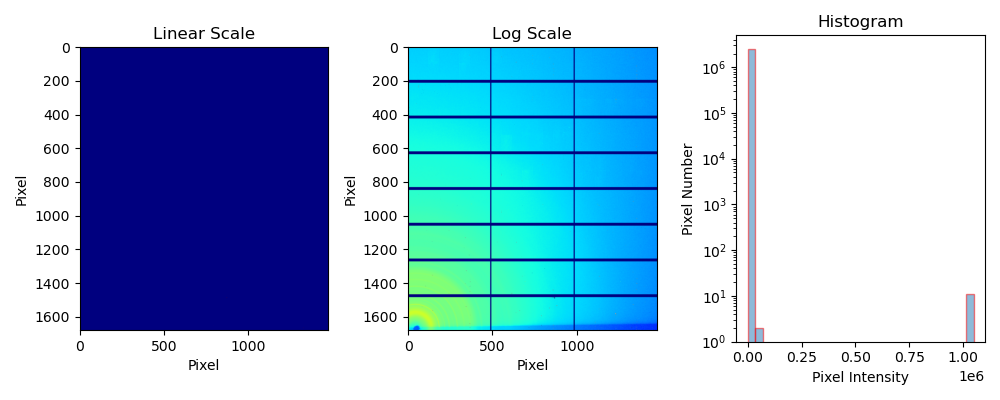

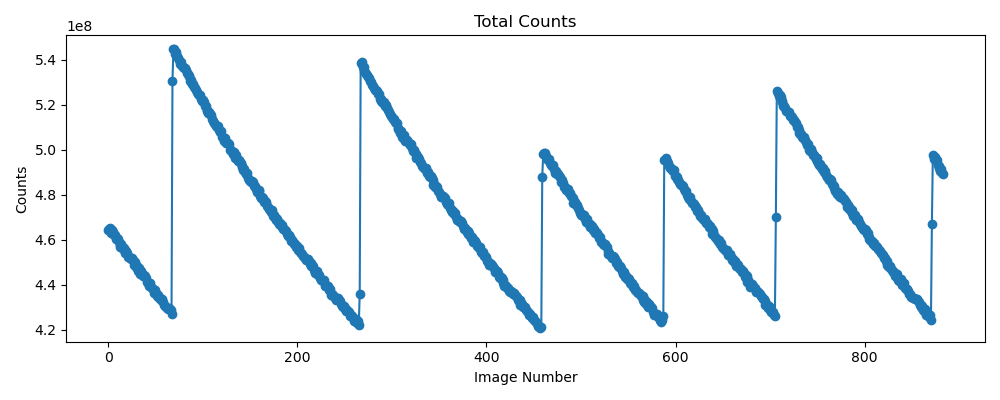

dict_keys(['images', 'sample_name', 'fluence', 'delay', 'image_number', 'counts', 'file_names'])
Images shape: (884, 1679, 1475)
Counts shape: (884,)
Unique delays: [-8.e-08 -5.e-09  6.e-10]


In [ ]:
data_dict = trxrd.get_image_details(
    folder_path=DATA_PATH,
    sample_name=SCAN_NAME,   
    sort=True,
    filter_data=False,
    plot=True,
)

print(data_dict.keys())
print("Images shape:", data_dict["images"].shape)
print("Counts shape:", data_dict["counts"].shape)
print("Unique delays:", np.unique(data_dict["delay"]))

## Find Centers for Images (Refined, multiprocess)

Finding centers for 3 images...
  Completed 3/3 (100.0%)
Done finding centers.


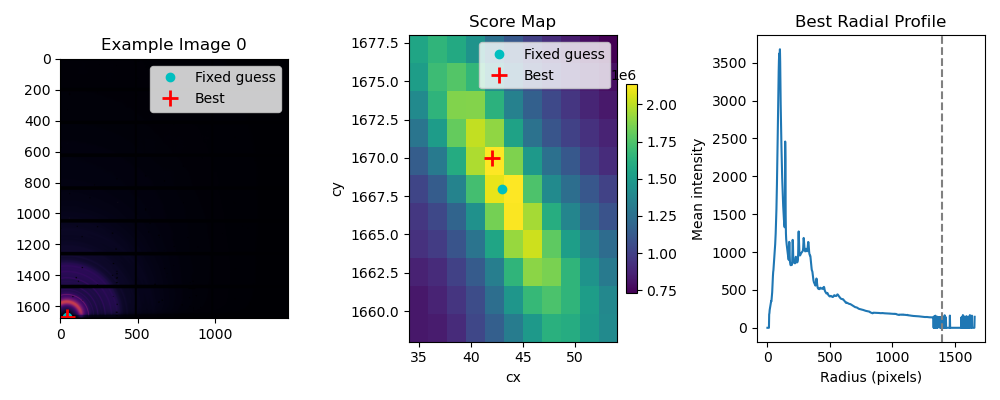

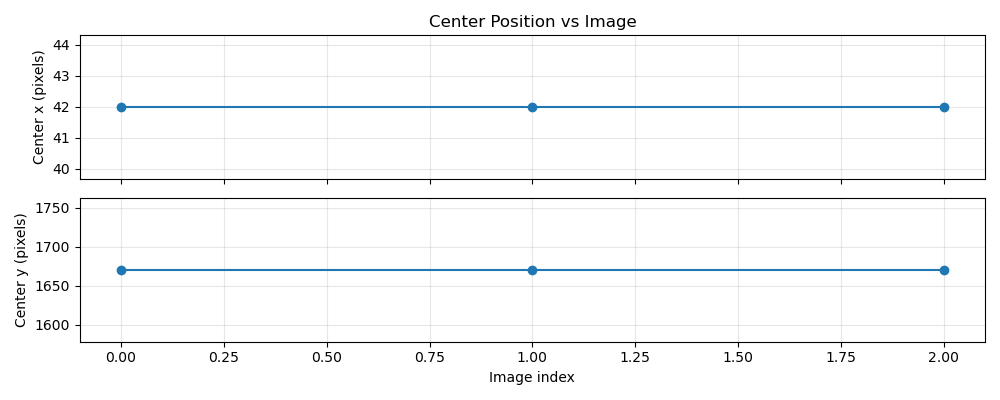

Centers shape: (3, 2)
First center: [  42. 1670.]
Mean center: [  42. 1670.]


In [ ]:
center_result = trxrd.find_centers_in_stack_radial_parallel(
    data_array=data_dict["images"],
    center_guess_yx=(CENTER_Y, CENTER_X),   # note: (y, x)
    search_radius=10,
    center_mask=None,
    r_min=0,
    r_max=1400,
    downsample=2,
    intensity_threshold=None,
    top_percentile=60,
    max_workers=MAX_PROCESSORS,
    progress_interval=100,
    plot_example=True,
    example_index=0,
    plot_center_vs_image=True,
)

centers = center_result["centers_xy"]
print("Centers shape:", centers.shape)
print("First center:", centers[0])
mean_center = np.mean(centers, axis=0)
print(f"Mean center: {mean_center}")